In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
import faiss

In [ ]:
# The SIFT dataset vectors are stored in .fvecs format. 
# Each vector entry starts with an int32 dimension prefix followed by that many float32 components.

def read_ivecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    return data[:, 1:]

def read_fvecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    # reinterpret everything except first column as float32
    vectors = data[:, 1:].view(np.float32)

    return vectors

BASE = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_base.fvecs"
QUERY = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_query.fvecs"
TRUTH = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_groundtruth.ivecs"

base_vectors = read_fvecs(BASE)
query_vectors = read_fvecs(QUERY)
truth_vectors = read_ivecs(TRUTH)

print(f"Dimensions of base: {base_vectors.shape}    Type: {base_vectors.dtype}")
print(f"Dimensions of query: {query_vectors.shape}    Type: {query_vectors.dtype}")
print(f"Dimensions of truth: {truth_vectors.shape}    Type: {truth_vectors.dtype}")

Dimensions of base: (10000, 128)    Type: float32
Dimensions of query: (100, 128)    Type: float32
Dimensions of truth: (100, 100)    Type: int32


In [3]:
n, d = base_vectors.shape
ids = np.arange(n)

In [4]:
# We use this to generate the "positive correlation" predicate, where similar vectors have the same predicate value.
def base_clusters(vectors, k, seed=42):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=1024,
        max_iter=100
    )
    return kmeans.fit_predict(vectors)

# For negative correlation we assign each vector a random label drawn from the other
# clusters (i.e. exclude its own cluster).  This breaks the alignment
# between spatial proximity and attribute equality and produces
# genuinely anticorrelated data.
def generate_negative(cluster_labels, k, seed=42):
    rng = np.random.default_rng(seed)
    # draw a label in [0, k) but not equal to the original
    # vectorised trick: sample from k-1 values then shift upward when
    # the sampled value is >= original label.
    n = len(cluster_labels)
    choices = rng.integers(0, k-1, size=n)
    # bump up those that would collide with the original label
    choices += (choices >= cluster_labels).astype(np.int64)
    return choices

# For "medium" correlation, we can randomly flip some fraction of the positive correlation labels.
def add_noise(attr, noise_fraction, k, seed=42):
    rng = np.random.default_rng(seed)
    noisy = attr.copy()
    n = len(attr)
    noise_idx = rng.choice(n, int(noise_fraction * n), replace=False)
    noisy[noise_idx] = rng.integers(0, k, size=len(noise_idx))
    return noisy

# For uncorrelated, we can just assign random values.
def generate_uncorrelated(n, k, seed=42):
    rng = np.random.default_rng(seed)
    return rng.integers(0, k, size=n)

In [5]:
### Positive correlation
attr_lc_pos = base_clusters(base_vectors, k=5)
attr_hc_pos = base_clusters(base_vectors, k=500)

In [6]:
### Negative correlation
attr_lc_neg = generate_negative(attr_lc_pos, k=5)
attr_hc_neg = generate_negative(attr_hc_pos, k=500)

In [7]:
### Medium correlation (add noise to positive correlation)
attr_lc_med = add_noise(attr_lc_pos, noise_fraction=0.3, k=5)
attr_hc_med = add_noise(attr_hc_pos, noise_fraction=0.3, k=500)

In [8]:
### Random, uncorrelated
attr_lc_rand = generate_uncorrelated(n, k=5)
attr_hc_rand = generate_uncorrelated(n, k=500)

In [9]:
index_flat = faiss.IndexFlatL2(d)
index_flat.add(base_vectors)

print(f"Total vectors in index: {index_flat.ntotal}")

distances, indices = index_flat.search(query_vectors, 10)

Total vectors in index: 10000


In [10]:
def recall_at_k(pred, gt, k):
    correct = 0
    total = pred.shape[0]
    
    for i in range(total):
        top_k_results = pred[i][:k] 
        ground_truth_k_neighbors = gt[i][:k]
        correct += len(set(top_k_results) & set(ground_truth_k_neighbors)) > 0
    return correct / total

print(f'Recall@10: {recall_at_k(indices, truth_vectors, 10)}')

Recall@10: 1.0


In [11]:
EPS = 1e-12

# ----------------------------
# Safe probability smoothing
# ----------------------------
def laplace_smooth(count, total, alpha=1.0):
    """
    Laplace smoothing for binary case.
    Returns smoothed probability.
    """
    return (count + alpha) / (total + 2 * alpha)


def safe_log(x):
    return np.log(np.clip(x, EPS, 1.0))

In [12]:
class CorrelationEstimator:
    def __init__(self, X, attr, n_clusters=40, random_state=42):
        self.X = X
        self.attr = attr

        # ---- Cluster once ----
        self.kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init="auto"
        )
        self.labels = self.kmeans.fit_predict(X)
        self.centroids = self.kmeans.cluster_centers_

        # ---- Precompute cluster -> indices mapping ----
        self.cluster_to_indices = {
            c: np.where(self.labels == c)[0]
            for c in range(n_clusters)
        }

    # --------------------------------------------------
    # Internal helpers
    # --------------------------------------------------

    def _nearest_clusters(self, q, top_L=10):
        distances = np.linalg.norm(self.centroids - q, axis=1)
        return np.argsort(distances)[:top_L]

    @staticmethod
    def _normalized_entropy(values):
        unique, counts = np.unique(values, return_counts=True)
        probs = counts / len(values)

        if len(probs) <= 1:
            return 0.0
 
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        max_entropy = np.log(len(probs))
        return entropy / max_entropy

    @staticmethod
    def _binary_entropy(p):
        if p <= 0.0 or p >= 1.0:
            return 0.0
        H = -p * np.log(p) - (1 - p) * np.log(1 - p)
        return H / np.log(2)   # normalize to [0,1]
    
    @staticmethod
    def _dispersion(X_subset, mask):
        if np.sum(mask) < 2:
            return 0.0

        X_p = X_subset[mask]

        mu_p = X_p.mean(axis=0)
        D_p = np.mean(np.sum((X_p - mu_p) ** 2, axis=1))

        mu_all = X_subset.mean(axis=0)
        D_all = np.mean(np.sum((X_subset - mu_all) ** 2, axis=1))

        if D_all == 0:
            return 0.0

        return np.clip(1 - D_p / D_all, 0, 1)

    # --------------------------------------------------
    # Query-level correlation
    # --------------------------------------------------

    def compute_query_level(self, q, predicate_fn, top_L=10):
        # 1. Get local region
        cluster_ids = self._nearest_clusters(q, top_L)

        local_indices = np.concatenate(
            [self.cluster_to_indices[c] for c in cluster_ids]
        )

        if len(local_indices) < 5:
            return 0.0

        X_local = self.X[local_indices]
        attr_local = self.attr[local_indices]

        # 2. Apply predicate
        mask = predicate_fn(attr_local)

        if mask.sum() < 2:
            return 0.0

        selectivity = mask.mean()

        # 3. Structural component
        H_bin = self._binary_entropy(selectivity)
        score_struct = 1 - H_bin

        # 4. Dispersion component
        disp = self._dispersion(X_local, mask)

        # 5. Final correlation
        corr_q = score_struct * disp

        return float(np.clip(corr_q, 0, 1))
    
    def signed_js_binary(self, local_mask, global_p, alpha=1.0):
        """
        Signed Jensen-Shannon divergence (binary case).
        """

        k = len(local_mask)
        count = local_mask.sum()

        # Laplace smoothing
        p_q = laplace_smooth(count, k, alpha)
        p = np.clip(global_p, EPS, 1 - EPS)

        # Mixture distribution
        m = 0.5 * (p_q + p)

        kl_local = (
            p_q * safe_log(p_q / m) +
            (1 - p_q) * safe_log((1 - p_q) / (1 - m))
        )

        kl_global = (
            p * safe_log(p / m) +
            (1 - p) * safe_log((1 - p) / (1 - m))
        )

        js = 0.5 * (kl_local + kl_global)

        direction = np.sign(p_q - p)
        signed_js = direction * js

        return {
            "signed_js": signed_js,
            "js_magnitude": js,
            "direction": direction,
            "p_q": p_q
        }
        
    def binary_stats(self, local_mask, global_p):
        """
        local_mask: boolean array of predicate in local region
        global_p: global probability of predicate
        """

        k = len(local_mask)
        count = local_mask.sum()
        p_q = count / k

        # 1️⃣ Direction
        direction = np.sign(p_q - global_p)

        # 2️⃣ Effect Size — Log Odds Ratio
        p_q_clip = np.clip(p_q, EPS, 1 - EPS)
        p_clip = np.clip(global_p, EPS, 1 - EPS)

        log_odds_ratio = np.log(
            (p_q_clip / (1 - p_q_clip)) /
            (p_clip / (1 - p_clip))
        )

        # 3️⃣ Significance — Z-score
        std = np.sqrt(global_p * (1 - global_p) / k)
        z = (p_q - global_p) / (std + EPS)

        return {
            "direction": direction,
            "effect_size_log_odds": log_odds_ratio,
            "z_score": z,
            "p_q": p_q
        }
    
    def continuous_stats(self, local_values, global_mean, global_std):
        """
        local_values: numeric attribute values in local region
        global_mean: global mean
        global_std: global std deviation
        """

        k = len(local_values)
        mu_q = np.mean(local_values)

        # 1️⃣ Direction
        direction = np.sign(mu_q - global_mean)

        # 2️⃣ Effect Size — Cohen's d
        cohen_d = (mu_q - global_mean) / (global_std + EPS)

        # 3️⃣ Significance — Z-score
        std_err = global_std / np.sqrt(k)
        z = (mu_q - global_mean) / (std_err + EPS)

        return {
            "direction": direction,
            "effect_size_cohen_d": cohen_d,
            "z_score": z,
            "mu_q": mu_q
        }
        
    def signed_kl_binary(self, local_mask, global_p, alpha=1.0):
        """
        Signed KL divergence between local Bernoulli and global Bernoulli.
        """

        k = len(local_mask)
        count = local_mask.sum()

        # Laplace smoothing
        p_q = laplace_smooth(count, k, alpha)

        p = np.clip(global_p, EPS, 1 - EPS)

        # KL divergence
        kl = (
            p_q * safe_log(p_q / p) +
            (1 - p_q) * safe_log((1 - p_q) / (1 - p))
        )

        direction = np.sign(p_q - p)

        signed_kl = direction * kl

        return {
            "signed_kl": signed_kl,
            "kl_magnitude": kl,
            "direction": direction,
            "p_q": p_q
        }   

In [13]:
# Is the predicate locally skewed? (low entropy)
# Are predicate embeddings locally tight? (high dispersion)
# Correlation is high only if BOTH hold.

### Build estimators for each attribute type
est_lc_pos = CorrelationEstimator(base_vectors, attr_lc_pos)
est_lc_neg = CorrelationEstimator(base_vectors, attr_lc_neg)
est_lc_med = CorrelationEstimator(base_vectors, attr_lc_med)
est_lc_rand = CorrelationEstimator(base_vectors, attr_lc_rand)

est_hc_pos = CorrelationEstimator(base_vectors, attr_hc_pos)
est_hc_neg = CorrelationEstimator(base_vectors, attr_hc_neg)
est_hc_med = CorrelationEstimator(base_vectors, attr_hc_med)
est_hc_rand = CorrelationEstimator(base_vectors, attr_hc_rand)


### Sample queries
rng = np.random.default_rng(42)
query_indices = rng.choice(len(query_vectors), size=100, replace=False)
sample_queries = query_vectors[query_indices]

def make_predicate(value):
    return lambda a: a == value

def compute_distribution(estimator, attr):
    values = []
    for qi, q in zip(query_indices, sample_queries):
        pred_value = attr[qi]   # aligned predicate
        pred = make_predicate(pred_value)
        values.append(estimator.compute_query_level(q, pred))
    return values

corr_pos = compute_distribution(est_lc_pos, attr_lc_pos)
corr_rand = compute_distribution(est_lc_rand, attr_lc_rand)
corr_neg = compute_distribution(est_lc_neg, attr_lc_neg)
corr_med = compute_distribution(est_lc_med, attr_lc_med)

hc_pos = compute_distribution(est_lc_pos, attr_hc_pos)
hc_rand = compute_distribution(est_hc_rand, attr_hc_rand)
hc_neg = compute_distribution(est_hc_neg, attr_hc_neg)
hc_med = compute_distribution(est_hc_med, attr_hc_med)


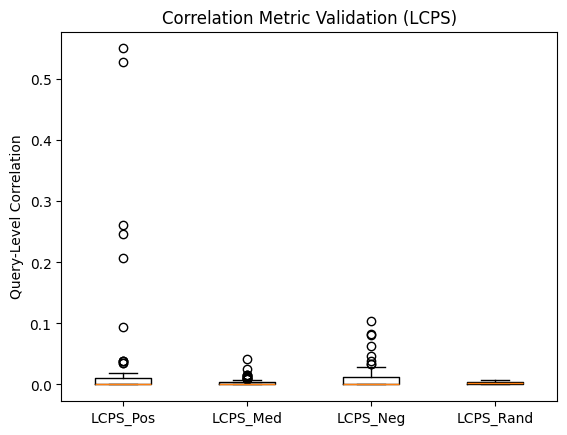

In [14]:
plt.figure()
plt.boxplot([corr_pos, corr_med, corr_neg, corr_rand])
plt.xticks([1,2,3,4], ["LCPS_Pos", "LCPS_Med", "LCPS_Neg", "LCPS_Rand"])
plt.ylabel("Query-Level Correlation")
plt.title("Correlation Metric Validation (LCPS)")
plt.show()

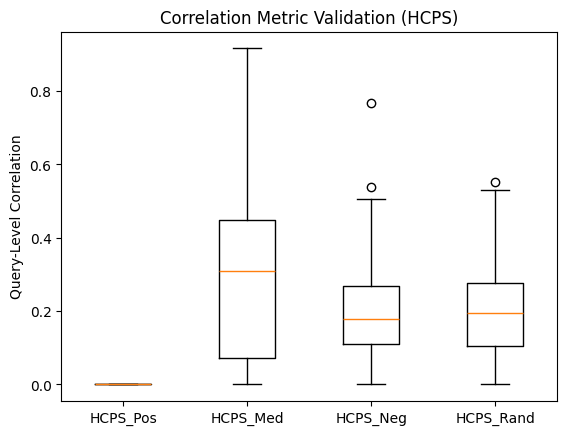

In [15]:
plt.figure()
plt.boxplot([hc_pos, hc_med, hc_neg, hc_rand])
plt.xticks([1,2,3,4], ["HCPS_Pos", "HCPS_Med", "HCPS_Neg", "HCPS_Rand"])
plt.ylabel("Query-Level Correlation")
plt.title("Correlation Metric Validation (HCPS)")
plt.show()

In [16]:
""" 
For numeric attribute A:
    Global mean μ
    Global variance σ^2
    CDF sketch (histogram or t-digest)

For categorical attribute:
    Global frequency table
    
Storage is O(#attributes)

Suppose the query is price < t. We already have:
    k nearest neighbour IDs
    attribute values for those k items
    
Local selectivity p_q --> #{A<t} / k
Global selectivity p --> from CDF --> p = F(t)

Standardized deviation --> Z = (p_q - p) / sqrt(p(1-p) / k)
Z > 0 --> positive correlation
Z < 0 --> negative correlation
Z ~ 0 --> random
"""

' \nFor numeric attribute A:\n    Global mean μ\n    Global variance σ^2\n    CDF sketch (histogram or t-digest)\n\nFor categorical attribute:\n    Global frequency table\n\nStorage is O(#attributes)\n\nSuppose the query is price < t. We already have:\n    k nearest neighbour IDs\n    attribute values for those k items\n\nLocal selectivity p_q --> #{A<t} / k\nGlobal selectivity p --> from CDF --> p = F(t)\n\nStandardized deviation --> Z = (p_q - p) / sqrt(p(1-p) / k)\nZ > 0 --> positive correlation\nZ < 0 --> negative correlation\nZ ~ 0 --> random\n'

In [17]:
rng = np.random.default_rng(42)
query_indices = rng.choice(len(query_vectors), size=100, replace=False)
sample_queries = query_vectors[query_indices]

# Build estimators (unchanged)
est_lc_pos  = CorrelationEstimator(base_vectors, attr_lc_pos)
est_lc_neg  = CorrelationEstimator(base_vectors, attr_lc_neg)
est_lc_med  = CorrelationEstimator(base_vectors, attr_lc_med)
est_lc_rand = CorrelationEstimator(base_vectors, attr_lc_rand)

est_hc_pos  = CorrelationEstimator(base_vectors, attr_hc_pos)
est_hc_neg  = CorrelationEstimator(base_vectors, attr_hc_neg)
est_hc_med  = CorrelationEstimator(base_vectors, attr_hc_med)
est_hc_rand = CorrelationEstimator(base_vectors, attr_hc_rand)

In [18]:
def compute_binary_distribution(estimator, attr):
    direction = []
    effect = []
    zscores = []

    for qi, q in zip(query_indices, sample_queries):
        pred_value = attr[qi]
        pred = make_predicate(pred_value)

        local_indices = estimator._nearest_clusters(q)
        local_indices = np.concatenate(
            [estimator.cluster_to_indices[c] for c in local_indices]
        )

        if len(local_indices) < 5:
            direction.append(0)
            effect.append(0)
            zscores.append(0)
            continue

        local_attr = attr[local_indices]
        mask = pred(local_attr)

        if mask.sum() < 2:
            direction.append(0)
            effect.append(0)
            zscores.append(0)
            continue

        # Use new stats
        stats = estimator.binary_stats(mask, np.mean(attr == pred_value))

        direction.append(stats["direction"])
        effect.append(stats["effect_size_log_odds"])
        zscores.append(stats["z_score"])

    return np.array(direction), np.array(effect), np.array(zscores)

In [19]:
def compute_signed_kl_distribution(estimator, attr):
    values = []

    for qi, q in zip(query_indices, sample_queries):
        pred_value = attr[qi]
        pred = make_predicate(pred_value)

        local_indices = estimator._nearest_clusters(q)
        local_indices = np.concatenate(
            [estimator.cluster_to_indices[c] for c in local_indices]
        )

        if len(local_indices) < 5:
            values.append(0)
            continue

        local_attr = attr[local_indices]
        mask = pred(local_attr)

        if mask.sum() < 2:
            values.append(0)
            continue

        global_p = np.mean(attr == pred_value)

        stats = estimator.signed_kl_binary(mask, global_p)
        values.append(stats["signed_kl"])

    return np.array(values)

In [20]:
def compute_signed_js_distribution(estimator, attr):
    values = []

    for qi, q in zip(query_indices, sample_queries):
        pred_value = attr[qi]
        pred = make_predicate(pred_value)

        local_indices = estimator._nearest_clusters(q)
        local_indices = np.concatenate(
            [estimator.cluster_to_indices[c] for c in local_indices]
        )

        if len(local_indices) < 5:
            values.append(0)
            continue

        local_attr = attr[local_indices]
        mask = pred(local_attr)

        if mask.sum() < 2:
            values.append(0)
            continue

        global_p = np.mean(attr == pred_value)

        stats = estimator.signed_js_binary(mask, global_p)
        values.append(stats["signed_js"])

    return np.array(values)

In [21]:
# Low correlation (positive)
dir_pos, eff_pos, z_pos = compute_binary_distribution(est_lc_pos, attr_lc_pos)
kl_pos = compute_signed_kl_distribution(est_lc_pos, attr_lc_pos)
js_pos = compute_signed_js_distribution(est_lc_pos, attr_lc_pos)

# Random
dir_rand, eff_rand, z_rand = compute_binary_distribution(est_lc_rand, attr_lc_rand)
kl_rand = compute_signed_kl_distribution(est_lc_rand, attr_lc_rand)
js_rand = compute_signed_js_distribution(est_lc_rand, attr_lc_rand)

# Negative
dir_neg, eff_neg, z_neg = compute_binary_distribution(est_lc_neg, attr_lc_neg)
kl_neg = compute_signed_kl_distribution(est_lc_neg, attr_lc_neg)
js_neg = compute_signed_js_distribution(est_lc_neg, attr_lc_neg)

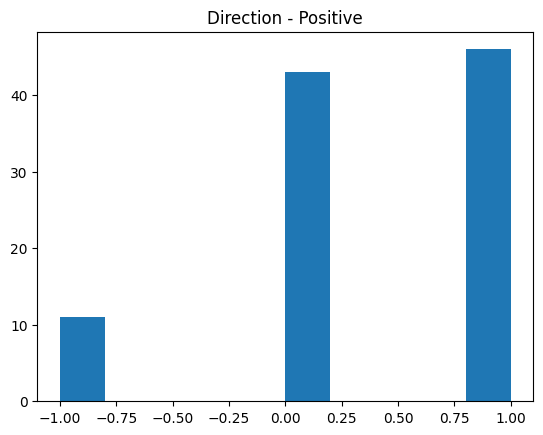

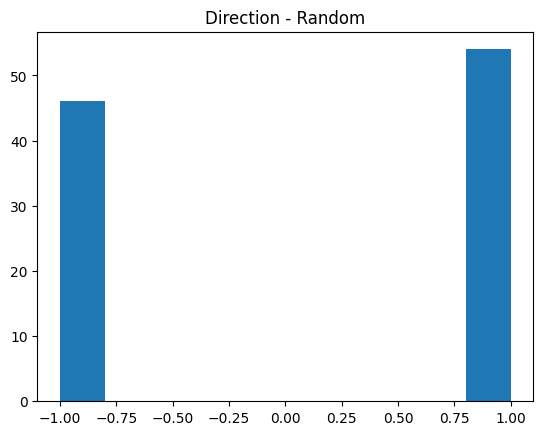

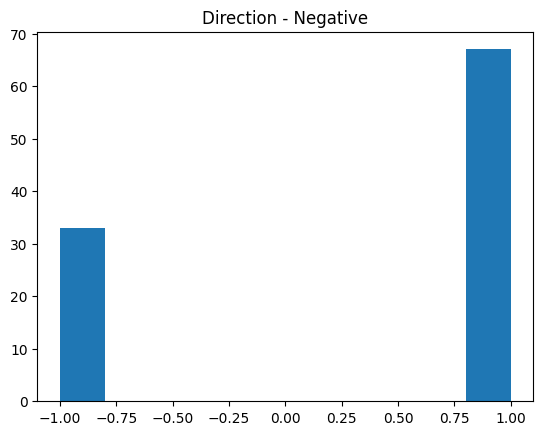

In [22]:
plt.figure()
plt.hist(dir_pos)
plt.title("Direction - Positive")
plt.show()

plt.figure()
plt.hist(dir_rand)
plt.title("Direction - Random")
plt.show()

plt.figure()
plt.hist(dir_neg)
plt.title("Direction - Negative")
plt.show()

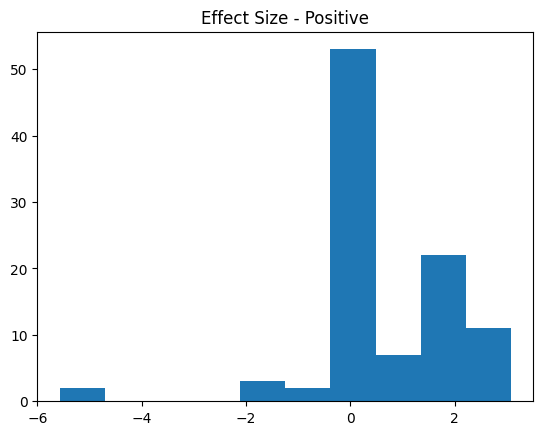

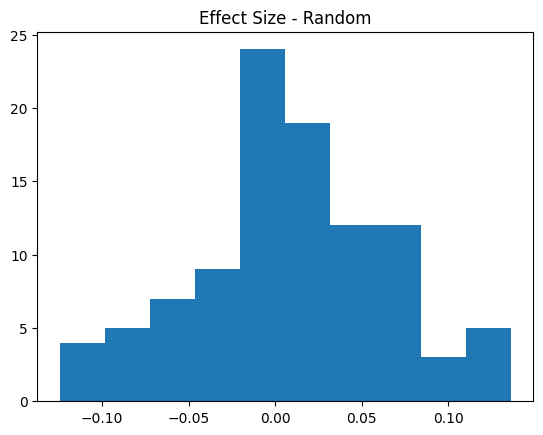

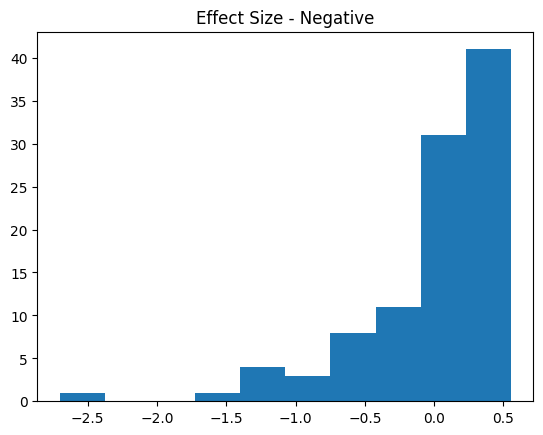

In [23]:
plt.figure()
plt.hist(eff_pos)
plt.title("Effect Size - Positive")
plt.show()

plt.figure()
plt.hist(eff_rand)
plt.title("Effect Size - Random")
plt.show()

plt.figure()
plt.hist(eff_neg)
plt.title("Effect Size - Negative")
plt.show()

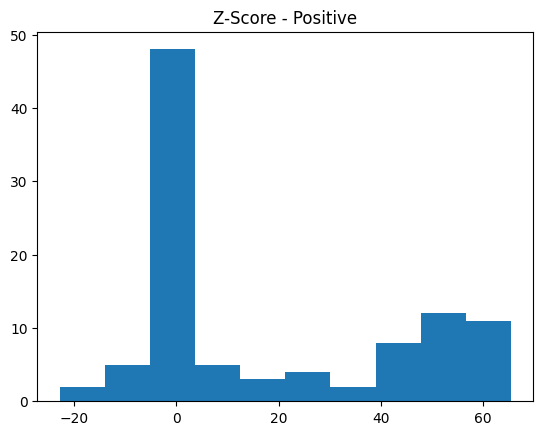

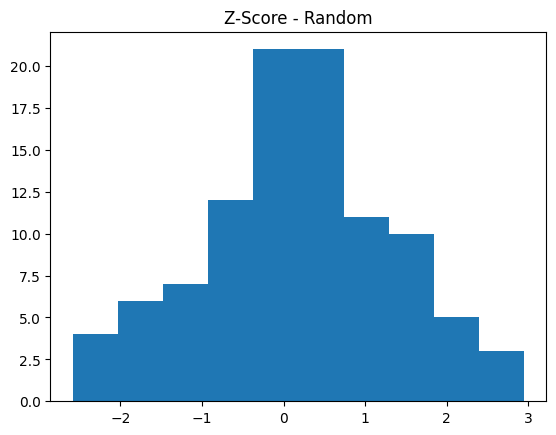

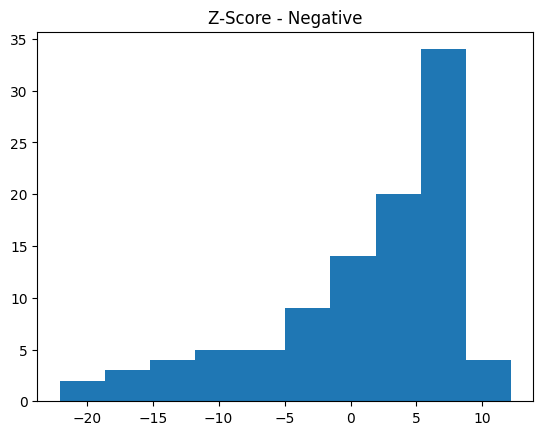

In [24]:
plt.figure()
plt.hist(z_pos)
plt.title("Z-Score - Positive")
plt.show()

plt.figure()
plt.hist(z_rand)
plt.title("Z-Score - Random")
plt.show()

plt.figure()
plt.hist(z_neg)
plt.title("Z-Score - Negative")
plt.show()

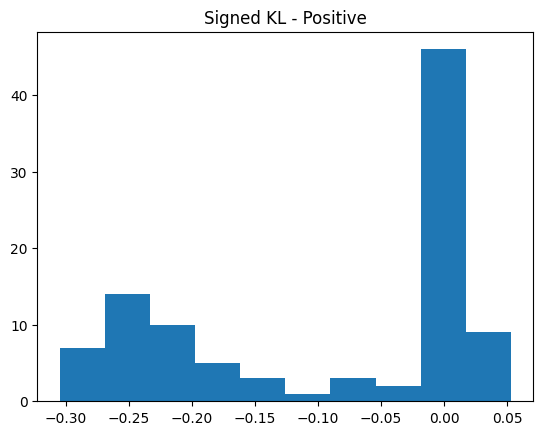

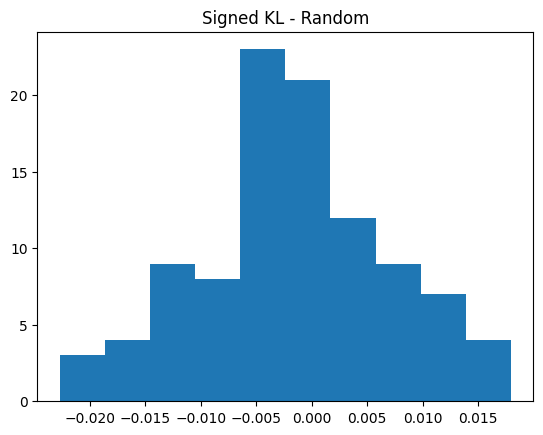

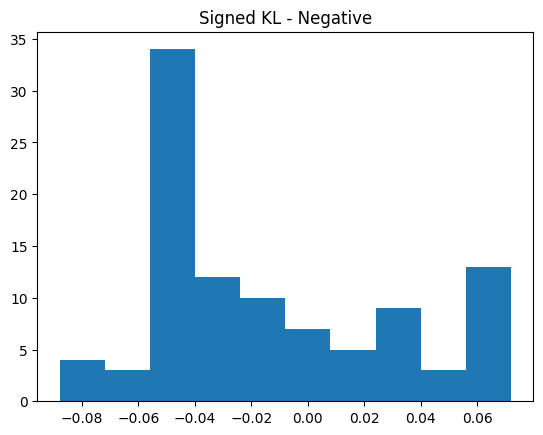

In [25]:
plt.figure()
plt.hist(kl_pos)
plt.title("Signed KL - Positive")
plt.show()

plt.figure()
plt.hist(kl_rand)
plt.title("Signed KL - Random")
plt.show()

plt.figure()
plt.hist(kl_neg)
plt.title("Signed KL - Negative")
plt.show()

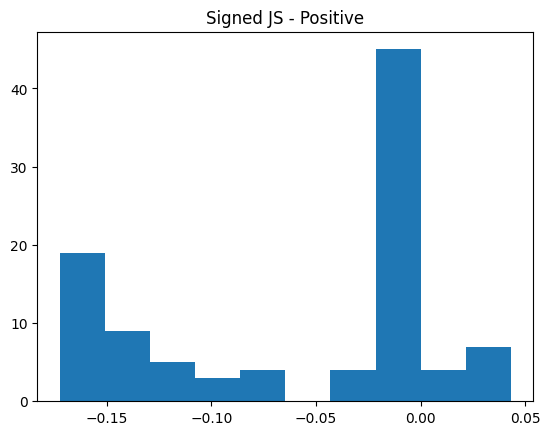

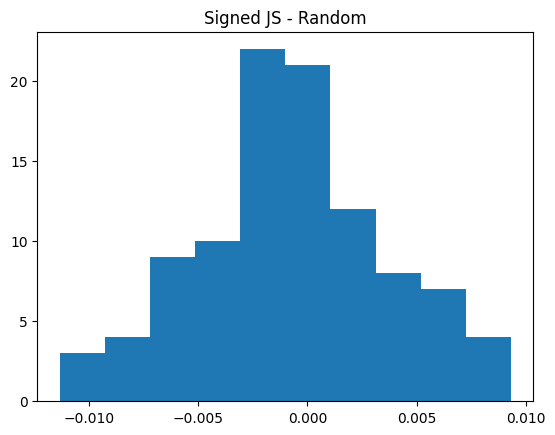

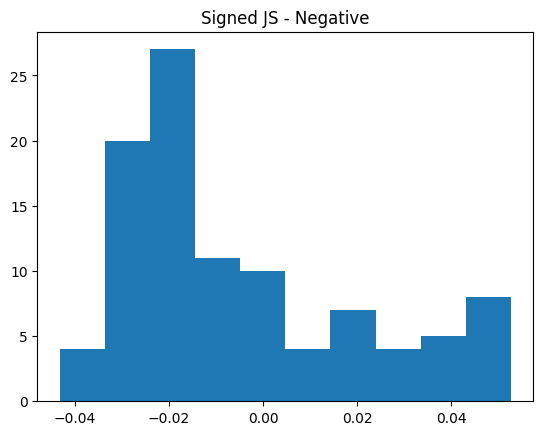

In [26]:
plt.figure()
plt.hist(js_pos)
plt.title("Signed JS - Positive")
plt.show()

plt.figure()
plt.hist(js_rand)
plt.title("Signed JS - Random")
plt.show()

plt.figure()
plt.hist(js_neg)
plt.title("Signed JS - Negative")
plt.show()